In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
from iminuit import Minuit

hep.style.use("LHCb")

# Load data and re-apply the same cuts as Step 2
df = pd.read_csv("D:/b_meson_analysis/charm_baryon_analysis/data/lc_candidates.csv")

df = df[
    (df["p_PROBNNp"] > 0.5) &
    (df["K_PROBNNk"] > 0.3) &
    (df["pi_PROBNNpi"] > 0.3) &
    (df["Lc_ENDVERTEX_CHI2"] < 5)
]

print("Selected events:", len(df))

data = df["Lc_M"].values

Selected events: 96184


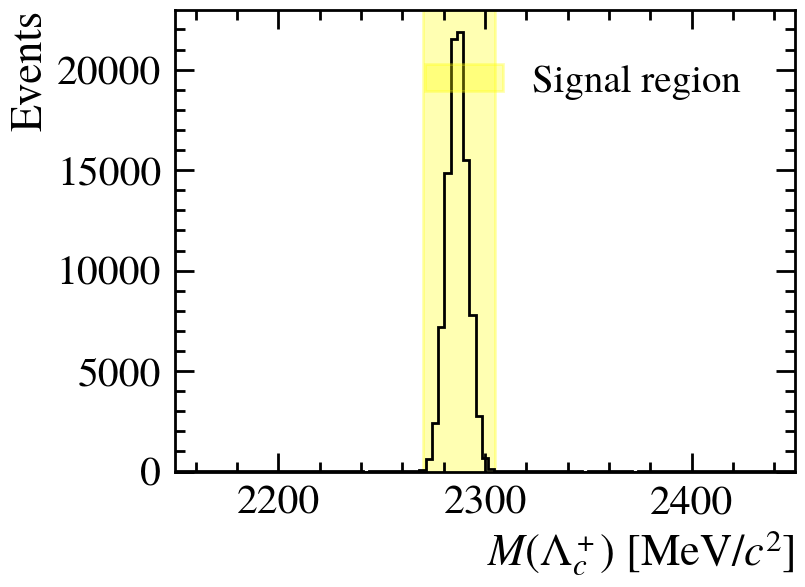

In [2]:
plt.figure(figsize=(8,6))

bins = np.linspace(2150, 2450, 100)

plt.hist(data, bins=bins, histtype="step", color="black")

plt.axvspan(2270, 2305, color="yellow", alpha=0.3, label="Signal region")

plt.xlabel(r"$M(\Lambda_c^+)$ [MeV/$c^2$]")
plt.ylabel("Events")
plt.legend()

plt.savefig("D:/b_meson_analysis/charm_baryon_analysis/plots/Lc_mass_raw.png")
plt.show()

In [3]:
def crystalball(x, mu, sigma, alpha, n):
    x = np.array(x)
    t = (x - mu) / sigma

    A = (n/abs(alpha))**n * np.exp(-alpha**2 / 2)
    B = n/abs(alpha) - abs(alpha)

    result = np.where(
        t > -alpha,
        np.exp(-0.5 * t**2),
        A * (B - t)**(-n)
    )

    return result


def normalize_pdf(pdf_vals, x):
    area = np.trapezoid(pdf_vals, x)
    return pdf_vals / area

In [4]:
def chebychev(x, c1, c2):
    # map x to [-1, 1]
    x_scaled = 2 * (x - 2150) / (2450 - 2150) - 1

    T1 = x_scaled
    T2 = 2 * x_scaled**2 - 1

    return 1 + c1*T1 + c2*T2

In [5]:
def total_pdf(x, N_sig, N_bkg, mu, sigma, alpha, n, c1, c2):
    sig = crystalball(x, mu, sigma, alpha, n)
    bkg = chebychev(x, c1, c2)

    sig = normalize_pdf(sig, x)
    bkg = normalize_pdf(bkg, x)

    return N_sig * sig + N_bkg * bkg

In [6]:
def nll(N_sig, N_bkg, mu, sigma, alpha, n, c1, c2):
    pdf_vals = total_pdf(data, N_sig, N_bkg, mu, sigma, alpha, n, c1, c2)

    # numerical stability
    pdf_vals = np.clip(pdf_vals, 1e-10, None)

    return -np.sum(np.log(pdf_vals))

In [7]:
m = Minuit(
    nll,
    N_sig=10000,
    N_bkg=10000,
    mu=2286.5,
    sigma=5.0,
    alpha=1.5,
    n=3.0,
    c1=0.0,
    c2=0.0
)

# Limits (VERY IMPORTANT for stability)
m.limits["N_sig"] = (0, None)
m.limits["N_bkg"] = (0, None)
m.limits["sigma"] = (1, 20)
m.limits["alpha"] = (0.5, 5)
m.limits["n"] = (1, 10)

m.migrad()
m.hesse()

print(m)

C:\Users\pc\AppData\Local\Temp\ipykernel_2680\1332772112.py:11: RuntimeWarning: invalid value encountered in power
  A * (B - t)**(-n)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -3.922e+06                 │             Nfcn = 1545              │
│ EDM = 5.94e+05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│           Hesse FAILED           │       Covariance NOT pos. def.       │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬─────

In [8]:
params = {name: m.values[name] for name in m.parameters}
errors = {name: m.errors[name] for name in m.parameters}

print("\nFit Results:")
for k in params:
    print(f"{k} = {params[k]:.3f} ± {errors[k]:.3f}")


Fit Results:
N_sig = 2798.335 ± 0.000
N_bkg = 17256.169 ± 0.000
mu = 2287.122 ± 0.000
sigma = 3.392 ± 0.000
alpha = 1.067 ± 0.000
n = 3.854 ± 0.000
c1 = -2.096 ± 0.000
c2 = -0.429 ± 0.000


C:\Users\pc\AppData\Local\Temp\ipykernel_2680\1332772112.py:11: RuntimeWarning: invalid value encountered in power
  A * (B - t)**(-n)


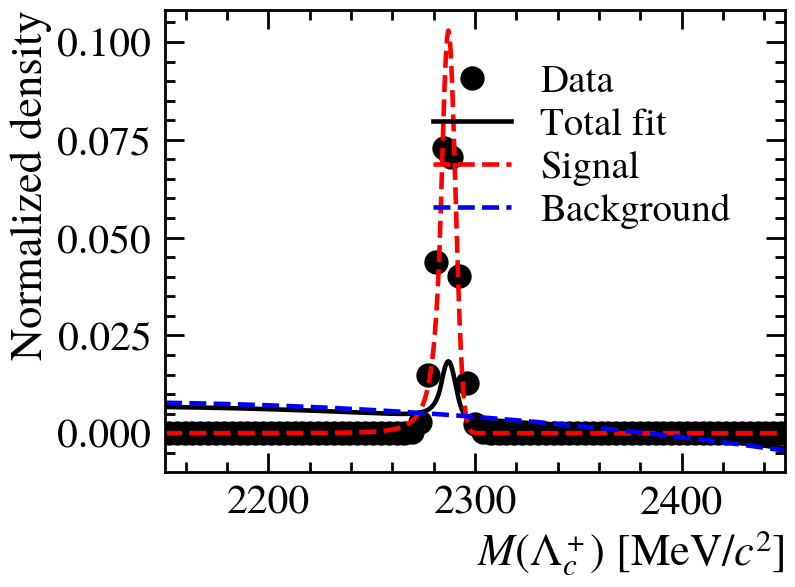

In [12]:
# --- HISTOGRAM (NORMALIZED) ---
bins = np.linspace(2150, 2450, 80)
hist, edges = np.histogram(data, bins=bins, density=True)
centers = 0.5 * (edges[1:] + edges[:-1])

# --- SMOOTH CURVES ---
x_plot = np.linspace(2150, 2450, 500)

sig = crystalball(x_plot, params["mu"], params["sigma"],
                  params["alpha"], params["n"])
bkg = chebychev(x_plot, params["c1"], params["c2"])

sig = normalize_pdf(sig, x_plot)
bkg = normalize_pdf(bkg, x_plot)

# normalize components
y_sig = params["N_sig"] * sig
y_bkg = params["N_bkg"] * bkg
y_tot = y_sig + y_bkg

# normalize total
y_tot /= np.trapezoid(y_tot, x_plot)
y_sig /= np.trapezoid(y_sig, x_plot)
y_bkg /= np.trapezoid(y_bkg, x_plot)

# --- PLOT ---
plt.figure(figsize=(8,6))

plt.plot(centers, hist, 'o', color='black', label="Data")

plt.plot(x_plot, y_tot, color="black", label="Total fit")
plt.plot(x_plot, y_sig, "--", color="red", label="Signal")
plt.plot(x_plot, y_bkg, "--", color="blue", label="Background")

plt.xlabel(r"$M(\Lambda_c^+)$ [MeV/$c^2$]")
plt.ylabel("Normalized density")

plt.legend()

plt.savefig("D:/b_meson_analysis/charm_baryon_analysis/plots/Lc_mass_fit_density.png")
plt.show()

In [13]:
import json

# Convert params to normal Python floats
fit_results = {k: float(params[k]) for k in params}

# Save file
with open("D:/b_meson_analysis/charm_baryon_analysis/results/fit_results.json", "w") as f:
    json.dump(fit_results, f, indent=4)

print("Fit results saved successfully!")

Fit results saved successfully!
